In [1]:
# GridSearchCV
!pip install kagglehub


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


# Retail Product Dataset with Missing Values

The dataset includes:

Category (Categorical): Product category (A, B, C, D)
Price (Numerical): Randomized product prices
Rating (Numerical): Ratings between 1 to 5
Stock (Categorical): Availability status (In Stock, Out of Stock)
Discount (Numerical): Discount percentag

In [5]:
#importar librerias
!pip install pandas numpy matplotlib


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\yered\OneDrive\Escritorio\Cursos\Machine Learning con Python\RegrecionesLineales\Clase 2\synthetic_dataset.csv")

In [4]:
df.head()

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0


In [5]:
#70% de preprocesamiento y un 30% del modelo
print(df.shape)
print(df.info())
print(df.isnull().sum())


(4362, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  1614 non-null   object 
 1   Price     4188 non-null   float64
 2   Rating    2312 non-null   float64
 3   Stock     3010 non-null   object 
 4   Discount  3970 non-null   float64
dtypes: float64(3), object(2)
memory usage: 170.5+ KB
None
Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64


In [7]:
#Estimacion de ventas
df["Sales"] = (800 - df["Price"].fillna(df["Price"].mean())+df["Rating"].fillna(df["Rating"].mean())+df["Discount"].fillna(df["Discount"].mean())+np.random.normal(0,50, size=df.shape[0]))

In [8]:
#Variable X e y
X = df.drop(["Sales"],axis=1)
y = df["Sales"]

In [9]:
#Separar varibales numericas y categoricas
numeric_features = X.select_dtypes(include = ["int64","float64"]).columns
categorical_features = X.select_dtypes(include = [object]).columns

In [18]:
#Dividir el entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


# Que es un pipeline?
Un pipeline es una estructura se maneja con sickit-learn y nos permite encadenar varios pasos de procesamiento y un modelo final en solo objeto objeto. Todos los pasos se van a ejecutar en el orden en el que guardamos el pipeline
y de forma automatica cada que ejecutemos a fit (entrenmiento).
Se utiliza con el preprocesamiento (handcraft) por ende es facil cometer errores, aplicando el fit_tranform ya no se aplica de forma desordenada.

-Transformadores (fit y Transform) -> SimpleImputer o StandardScaler
- Estimadores (fit y predict como LinearRegression)



In [20]:
#Como se transforman los datos dummy y el uso de onehotencoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),("scaler", StandardScaler())
                             ])

In [21]:
from sklearn.preprocessing import OneHotEncoder
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [22]:
#libreria
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

#aplicamos preprocesamiento
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.fit_transform(X_test)

print("Forma de X_train_preprocessed:", X_train_preprocessed.shape)
print("Forma de X_test_preprocessed:", X_test_preprocessed.shape)

Forma de X_train_preprocessed: (3489, 9)
Forma de X_test_preprocessed: (873, 9)


In [27]:
#verifiquemos que ya no exista ningun NaN
print(np.isnan(X_train_preprocessed.toarray()).sum() if hasattr(X_train_preprocessed, "toarray") else np.isnan(X_train_preprocessed).sum())
print(np.isnan(X_test_preprocessed.toarray()).sum() if hasattr(X_test_preprocessed, "toarray") else np.isnan(X_test_preprocessed).sum())

0
0


In [29]:
#Obtenemos los nombres de las variables ya transformadas
num_names = numeric_features
#nombres categoricos despues del onehotencoder
cat_names = preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(categorical_features)
#unir los nombres
feature_names = np.concatenate([num_names, cat_names])
print("Nombres de las variables transformadas:", feature_names[:5])

Nombres de las variables transformadas: ['Price' 'Rating' 'Discount' 'Category_A' 'Category_B']


In [30]:
#Convertir a dataframe 
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed.toarray() if hasattr(X_train_preprocessed, "toarray") else X_train_preprocessed, columns=feature_names)
X_train_preprocessed_df.head()

,Price,Rating,Discount,Category_A,Category_B,Category_C,Category_D,Stock_In Stock,Stock_Out of Stock
0,0.086258,-0.503762,0.888238,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.310659,0.000000,0.815541,0.0,0.0,1.0,0.0,0.0,1.0
2,0.990405,0.609248,-1.801534,0.0,0.0,1.0,0.0,1.0,0.0
3,0.657298,0.000000,-1.219962,0.0,0.0,1.0,0.0,1.0,0.0
4,1.430943,0.000000,0.161273,0.0,0.0,1.0,0.0,1.0,0.0


In [32]:
#Entrenamiento del modelo
from sklearn.linear_model import LinearRegression
linear_pipeline = Pipeline([("Preprocessor", preprocessor), ("model",LinearRegression())])
linear_pipeline.fit(X_train,y_train)
y_pred = linear_pipeline.predict(X_test)
print("Predicciones:", y_pred[:5])
#Comparacion
comparison_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(comparison_df.head())

Predicciones: [-7881.97351432 -3932.8497961    424.96465393 -3986.11920707
 -4856.12654445]
           Actual    Predicted
179  -7872.533195 -7881.973514
3167 -3882.088152 -3932.849796
2740   408.470272   424.964654
2191 -3991.886171 -3986.119207
1578 -4911.849911 -4856.126544


In [ ]:
#Metricas para ver que tan cercano o que tan bien aprendio el modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)
print("MAE: ", mae, " MSE: ", mse, " R2: ", r2_score)
#R2 entre mas cercano a 1 es mejor y mas cercano a 0 es peor

MAE:  42.101135439856655  MSE:  2769.2080126981  R2:  0.9996493251588237


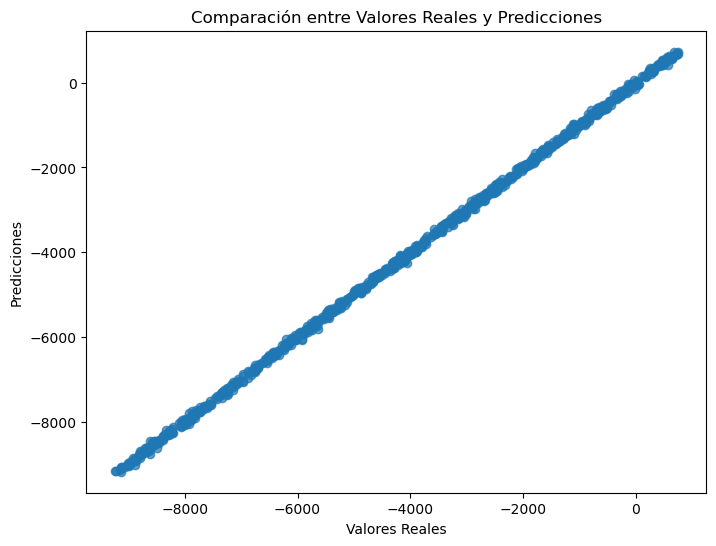

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Comparación entre Valores Reales y Predicciones")
plt.show()

In [36]:
#Category	Price	Rating	Stock	Discount
new_data = pd.DataFrame({
    "Category": ["B"],
    "Price": [230],
    "Rating":[5],
    "Stock":["In Stock"],
    "Discount":[2]
})
#venta real
venta_real = 817
prediction = linear_pipeline.predict(new_data)
print("ventas estimadas: ", prediction[0])

ventas estimadas:  579.9939529579033


# Criterios para crear un pipeline

1. Identificar los Datos 
- Numericos
- categoricos
- Texto
- Fechas
Los datos numericos tienen que reciben preprocesmiento y estos se dan de diferente forma a los categoricos.

2. Identificar los datos faltates (Null y los NaN)
Numericos: SimpleImputer(strategy = 'mean')
Categoricas: SimpleImputer(Strategy = 'most_frequency')

3. Variables categoricas
OneHotEncoder() -> Datos categoricos
-> Object -> Ciudad_CDMX, Ciudad_Guadalajara

4. Escalado 
- KNN -> Mi algoritmo usa distancias?
- KNN, SVM, K-Means, Redes Neuronales, PCA
- Necesitamos escalar -> StandardScaler() 0 MinMaxScaler()

5. Seleccion de variables
Cuando existen muchas caracteristicas
SelectKBest()
RFE()
PCA() Vectores propios y valores propios.

6. Transformaciones especiales.
VAriables con distribuciones sesgadas.
Datos:
10000
15000
18000
50000
100000000

np.log() o PowerTransformer()

7. Modelos a Utilizar

Pipeline agregabamos datos preprocesados y posteriormente ya implementabamos el modelo LinearRegression(), RandomForestRegressor(), DecisionTreeClassifier(), KNeighborsClassifier()

Estructure
Datos
/
/
/---------> Imputacion
/---------> Codificacion
/---------> Escalado
/---------> Seleccion de Variables
/---------> Modelo -> Lineales

